In [1]:
!pip install triton -q

In [2]:
import torch
import triton
import triton.language as tl

### Tiling Logic

In [ ]:
@triton.jit
def tiled_copy_kernel(
    input_ptr,
    op_ptr,
    M, N,
    stride_m,
    stride_n,
    Block_M: tl.constexpr,
    Block_N: tl.constexpr
): 
   pid_m = tl.program_id(0)
   pid_n = tl.program_id(1)

   rm = pid_m * Block_M + tl.arange(0, Block_M)
   rn = pid_n * Block_N + tl.arange(0, Block_N)

   ptr = input_ptr + (rm[:, None]* stride_m + rn[None, :] * stride_n)

   mask = (rm[:, None] < M) & (rn[None, :] <N)

   data = tl.load(ptr, mask=mask)

   out_ptr = op_ptr + (rm[:, None] * stride_m + rn[None, :] * stride_n)
   tl.store(out_ptr, data, mask=mask)


def triton_helper(x: torch.tensor):
    M, N = x.shape
    output = torch.empty_like(x)
 
    BLOCK_M, BLOCK_N = 32, 32
    
    # How many tiles do we need?
    # grid = (Number of Row Tiles, Number of Col Tiles)
    grid = (triton.cdiv(M, BLOCK_M), triton.cdiv(N, BLOCK_N))

    tiled_copy_kernel[grid](
        x, output,
        M, N,
        x.stride(0), x.stride(1), # Strides are critical!
        Block_M=BLOCK_M, Block_N=BLOCK_N
    )
    return output

# Test it
x = torch.randn((128, 128), device='cuda', dtype=torch.float16)
y = triton_helper(x)
torch.testing.assert_close(x, y)

## -------Online Softmax-----------

In [4]:
@triton.jit
def online_softmax_kernel(
    output_ptr, input_ptr, 
    stride_m,  # Distance between rows
    N_cols,    # Total columns
    BLOCK_SIZE: tl.constexpr
):
    # Each 'program' handles one row
    row_idx = tl.program_id(0)
    
    # Move pointer to the start of this specific row
    row_start_ptr = input_ptr + row_idx * stride_m
    
    # Initialize our "Running Stats"
    running_max = -float('inf')
    running_sum = 0.0
    
    for start_n in range(0, N_cols, BLOCK_SIZE):
        cols = start_n + tl.arange(0, BLOCK_SIZE)
        mask = cols < N_cols
        
        # 1. Load the chunk
        curr_chunk = tl.load(row_start_ptr + cols, mask=mask, other=-float('inf'))
        
        # 2. Find max of THIS chunk
        chunk_max = tl.max(curr_chunk, axis=0)
        
        # 3. Update Global Max
        new_max = tl.maximum(running_max, chunk_max)
        
        # 4. THE CORRECTION: Rescale the running sum
        # If new_max is bigger than running_max, we shrink the old sum
        scale_factor = tl.exp(running_max - new_max)
        running_sum = running_sum * scale_factor + tl.sum(tl.exp(curr_chunk - new_max), axis=0)
        
        # Update running_max for the next iteration
        running_max = new_max

    # 5. Final Pass: Write the result
    for start_n in range(0, N_cols, BLOCK_SIZE):
        cols = start_n + tl.arange(0, BLOCK_SIZE)
        mask = cols < N_cols
        curr_chunk = tl.load(row_start_ptr + cols, mask=mask, other=-float('inf'))
        
        # Final Softmax formula using our global stats
        softmax_out = tl.exp(curr_chunk - running_max) / running_sum
        
        out_ptr = output_ptr + row_idx * stride_m + cols
        tl.store(out_ptr, softmax_out, mask=mask)

def triton_online_softmax(x):
    M, N = x.shape
    output = torch.empty_like(x)
    BLOCK_SIZE = 1024 
    # Launch one program per row
    grid = (M,)
    
    online_softmax_kernel[grid](
        output, x, 
        x.stride(0), N, 
        BLOCK_SIZE=BLOCK_SIZE
    )
    return output

x = torch.randn((128, 4096), device='cuda', dtype=torch.float16)
y_triton = triton_online_softmax(x)
y_pytorch = torch.softmax(x, dim=-1)

torch.testing.assert_close(y_triton, y_pytorch, atol=1e-3, rtol=1e-3)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def benchmark_softmax(M=128):
    configs = [512, 1024, 2048, 4096, 8192]
    results = []

    for N in configs:
        x = torch.randn((M, N), device='cuda', dtype=torch.float16)
        
        # Benchmark PyTorch
        ms_pytorch = triton.testing.do_bench(lambda: torch.softmax(x, dim=-1))
        
        # Benchmark Triton
        ms_triton = triton.testing.do_bench(lambda: triton_online_softmax(x))
        
        results.append({
            'Width': N,
            'PyTorch (ms)': ms_pytorch,
            'Triton (ms)': ms_triton,
            'Speedup': ms_pytorch / ms_triton
        })

    return pd.DataFrame(results)

df = benchmark_softmax()

plt.figure(figsize=(10, 5))
plt.plot(df['Width'], df['PyTorch (ms)'], label='PyTorch', marker='o')
plt.plot(df['Width'], df['Triton (ms)'], label='Triton (Fused)', marker='s')
plt.title('Softmax Latency: PyTorch vs. Triton Online')
plt.xlabel('Row Width (Columns)')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True)
plt.show()

print(df)

## ---------- Fused Attention Forward Kernel -------------

 - The Fused Triton Kernel.
 - The PyTorch Baseline.
 - The Correctness Oracle.
 - The VRAM Memory Profiler.
 - The Latency Benchmarker.
 - The Matplotlib Visualization

Starting Comprehensive Evaluation...

Testing Sequence Length: 512...
Testing Sequence Length: 1024...
Testing Sequence Length: 2048...
Testing Sequence Length: 4096...

=== FINAL METRICS ===
 Seq_Len  PyTorch_ms  Triton_ms  PyTorch_VRAM_MB  Triton_VRAM_MB  Speedup
     512    0.356015   2.344263           30.125          15.125 0.151867
    1024    1.035467   8.597482           85.125          22.125 0.120438
    2048    4.017795  34.417345          290.125          36.125 0.116738
    4096   18.278317 136.509216         1084.125          64.125 0.133898


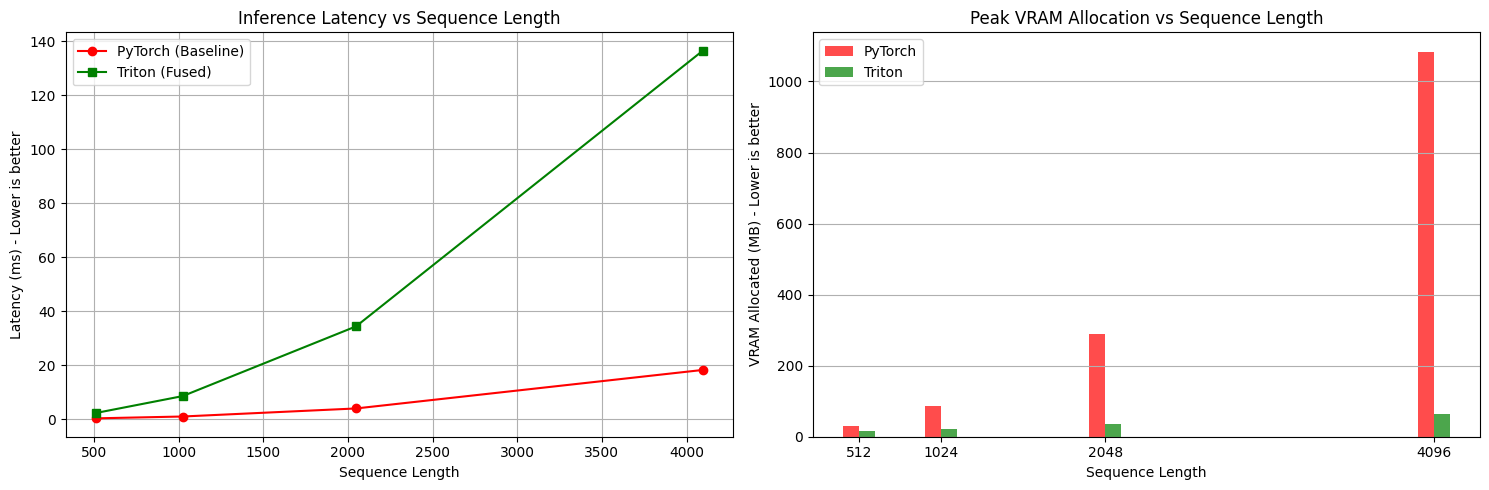

In [ ]:
import torch
import triton
import triton.language as tl
import pandas as pd
import matplotlib.pyplot as plt

# THE TRITON KERNEL (without autotuning)
@triton.jit
def fused_attention_forward_kernel(
    Q, K, V, sm_scale, Out,
    stride_qb, stride_qh, stride_qm, stride_qd,
    stride_kb, stride_kh, stride_kn, stride_kd,
    stride_vb, stride_vh, stride_vn, stride_vd,
    stride_ob, stride_oh, stride_om, stride_od,
    seq_len, head_dim,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr
):
    batch_idx = tl.program_id(0)
    head_idx = tl.program_id(1)
    q_tile_idx = tl.program_id(2)

    # Offsets for this specific tile
    offs_m = q_tile_idx * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = tl.arange(0, BLOCK_N)
    offs_d = tl.arange(0, 64) # Hardcoded for head_dim=64 for T4 optimization

    # Base pointers for this batch/head
    q_ptrs = Q + (batch_idx * stride_qb + head_idx * stride_qh + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qd)
    
    # Initialize Running Stats in SRAM (fp32 for stability)
    m_i = tl.zeros([BLOCK_M], dtype=tl.float32) - float("inf") # Running Max
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)                # Running Sum
    acc = tl.zeros([BLOCK_M, 64], dtype=tl.float32)            # Output Accumulator

    # Load Q tile
    q = tl.load(q_ptrs, mask=(offs_m[:, None] < seq_len) & (offs_d[None, :] < head_dim), other=0.0)

    # Inner Loop: Stream K and V tiles
    for start_n in range(0, seq_len, BLOCK_N):
        start_n = tl.multiple_of(start_n, BLOCK_N)
        
        # Pointers for K and V tiles
        k_ptrs = K + (batch_idx * stride_kb + head_idx * stride_kh + (start_n + offs_n[None, :]) * stride_kn + offs_d[:, None] * stride_kd)
        v_ptrs = V + (batch_idx * stride_vb + head_idx * stride_vh + (start_n + offs_n[:, None]) * stride_vn + offs_d[None, :] * stride_vd)

        # Load K and V
        # The Corrected Lines
        k = tl.load(k_ptrs, mask=((start_n + offs_n[None, :]) < seq_len) & (offs_d[:, None] < head_dim), other=0.0)
        v = tl.load(v_ptrs, mask=((start_n + offs_n[:, None]) < seq_len) & (offs_d[None, :] < head_dim), other=0.0)

        # Q @ K.T
        qk = tl.zeros([BLOCK_M, BLOCK_N], dtype=tl.float32)
        qk += tl.dot(q, k) * sm_scale
        
        # Mask sequence length limits
        qk = tl.where((offs_m[:, None] < seq_len) & ((start_n + offs_n[None, :]) < seq_len), qk, float("-inf"))

        # Online Softmax Math (Rescaling)
        m_ij = tl.max(qk, 1)
        m_new = tl.maximum(m_i, m_ij)
        alpha = tl.exp(m_i - m_new)
        
        p = tl.exp(qk - m_new[:, None])
        l_i = l_i * alpha + tl.sum(p, 1)
        
        # Update accumulator
        acc = acc * alpha[:, None]
        acc += tl.dot(p.to(tl.float16), v)
        m_i = m_new

    # Final division and store
    acc = acc / l_i[:, None]
    out_ptrs = Out + (batch_idx * stride_ob + head_idx * stride_oh + offs_m[:, None] * stride_om + offs_d[None, :] * stride_od)
    tl.store(out_ptrs, acc.to(tl.float16), mask=(offs_m[:, None] < seq_len) & (offs_d[None, :] < head_dim))

# WRAPPERS & BASELINE
def triton_fused_attention(q, k, v, sm_scale):
    B, H, S, D = q.shape
    out = torch.empty_like(q)
    BLOCK_M, BLOCK_N = 64, 64
    grid = (B, H, triton.cdiv(S, BLOCK_M))
    
    fused_attention_forward_kernel[grid](
        q, k, v, sm_scale, out,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        k.stride(0), k.stride(1), k.stride(2), k.stride(3),
        v.stride(0), v.stride(1), v.stride(2), v.stride(3),
        out.stride(0), out.stride(1), out.stride(2), out.stride(3),
        S, D, BLOCK_M=BLOCK_M, BLOCK_N=BLOCK_N
    )
    return out

def pytorch_attention(q, k, v, sm_scale):
    # Q @ K^T -> Creates the massive N x N intermediate tensor
    scores = torch.matmul(q, k.transpose(-2, -1)) * sm_scale
    
    # Softmax -> Creates ANOTHER massive N x N intermediate tensor
    probs = torch.nn.functional.softmax(scores, dim=-1)
    
    out = torch.matmul(probs, v)
    
    return out

# THE EVALUATION SUITE
def evaluate_and_plot():
    print("Starting Comprehensive Evaluation...\n")
    B, H, D = 2, 8, 64 
    seq_lengths = [512, 1024, 2048, 4096]
    sm_scale = 1.0 / (D ** 0.5)
    
    results = []

    for S in seq_lengths:
        print(f"Testing Sequence Length: {S}...")
        q = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)
        k = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)
        v = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)

        # --- CORRECTNESS CHECK ---
        out_pt = pytorch_attention(q, k, v, sm_scale)
        out_tr = triton_fused_attention(q, k, v, sm_scale)
        
        try:
            torch.testing.assert_close(out_tr, out_pt, atol=1e-2, rtol=1e-2)
            correct = True
        except AssertionError:
            correct = False
            print(f"  [!] Correctness Failed at S={S}")
            break

        # --- VRAM PROFILING ---
        # Measure PyTorch
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = pytorch_attention(q, k, v, sm_scale)
        vram_pt = torch.cuda.max_memory_allocated() / (1024**2) # Convert to MB

        # Measure Triton
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = triton_fused_attention(q, k, v, sm_scale)
        vram_tr = torch.cuda.max_memory_allocated() / (1024**2) # Convert to MB

        # --- LATENCY PROFILING ---
        ms_pt = triton.testing.do_bench(lambda: pytorch_attention(q, k, v, sm_scale))
        ms_tr = triton.testing.do_bench(lambda: triton_fused_attention(q, k, v, sm_scale))

        results.append({
            'Seq_Len': S,
            'PyTorch_ms': ms_pt,
            'Triton_ms': ms_tr,
            'PyTorch_VRAM_MB': vram_pt,
            'Triton_VRAM_MB': vram_tr,
            'Speedup': ms_pt / ms_tr
        })

    df = pd.DataFrame(results)
    print("\n=== FINAL METRICS ===")
    print(df.to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Latency
    ax1.plot(df['Seq_Len'], df['PyTorch_ms'], label='PyTorch (Baseline)', marker='o', color='red')
    ax1.plot(df['Seq_Len'], df['Triton_ms'], label='Triton (Fused)', marker='s', color='green')
    ax1.set_title('Inference Latency vs Sequence Length')
    ax1.set_xlabel('Sequence Length')
    ax1.set_ylabel('Latency (ms) - Lower is better')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: VRAM Usage
    ax2.bar(df['Seq_Len'] - 50, df['PyTorch_VRAM_MB'], width=100, label='PyTorch', color='red', alpha=0.7)
    ax2.bar(df['Seq_Len'] + 50, df['Triton_VRAM_MB'], width=100, label='Triton', color='green', alpha=0.7)
    ax2.set_title('Peak VRAM Allocation vs Sequence Length')
    ax2.set_xlabel('Sequence Length')
    ax2.set_ylabel('VRAM Allocated (MB) - Lower is better')
    ax2.set_xticks(df['Seq_Len'])
    ax2.legend()
    ax2.grid(axis='y')

    plt.tight_layout()
    plt.show()

evaluate_and_plot()

Starting Comprehensive Evaluation (Autotuned)...

Testing Sequence Length: 512...
Testing Sequence Length: 1024...
Testing Sequence Length: 2048...
Testing Sequence Length: 4096...

=== FINAL METRICS ===
 Seq_Len  PyTorch_ms  Triton_ms  PyTorch_VRAM_MB  Triton_VRAM_MB  Speedup
     512    0.274634   0.839415          310.125         295.125 0.327173
    1024    1.027582   3.186292          365.125         302.125 0.322501
    2048    4.071815  12.600555          570.125         316.125 0.323146
    4096   18.763360  51.109249         1364.125         344.125 0.367123


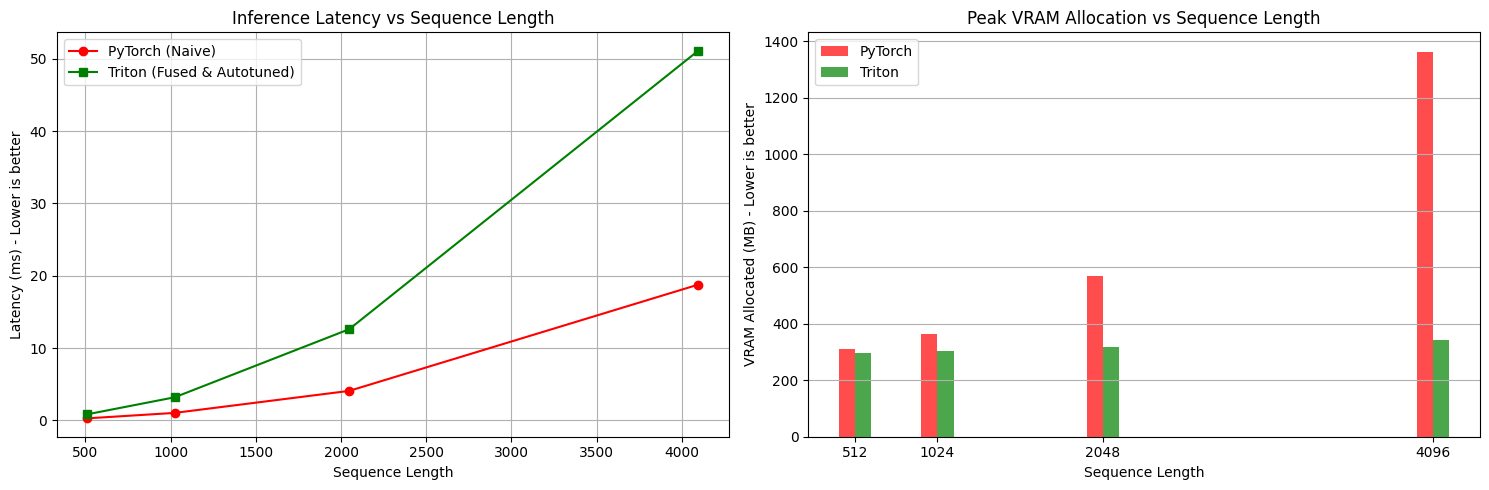

In [7]:
# THE TRITON KERNEL (WITH AUTOTUNING)
@triton.autotune(
    configs=[
        # Nvidia T4-specific search space: varying block sizes and warp thread counts
        triton.Config({'BLOCK_M': 128, 'BLOCK_N': 64}, num_warps=4, num_stages=1),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 128}, num_warps=4, num_stages=1),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 64}, num_warps=4, num_stages=1),
        triton.Config({'BLOCK_M': 64, 'BLOCK_N': 64}, num_warps=8, num_stages=1),
        triton.Config({'BLOCK_M': 32, 'BLOCK_N': 32}, num_warps=4, num_stages=1),
    ],
    key=['seq_len', 'head_dim']
)
@triton.jit
def fused_attention_forward_kernel(
    Q, K, V, sm_scale, Out,
    stride_qb, stride_qh, stride_qm, stride_qd,
    stride_kb, stride_kh, stride_kn, stride_kd,
    stride_vb, stride_vh, stride_vn, stride_vd,
    stride_ob, stride_oh, stride_om, stride_od,
    seq_len, head_dim,
    BLOCK_M: tl.constexpr, BLOCK_N: tl.constexpr
):
    batch_idx = tl.program_id(0)
    head_idx = tl.program_id(1)
    q_tile_idx = tl.program_id(2)

    # Offsets for this specific tile
    offs_m = q_tile_idx * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = tl.arange(0, BLOCK_N)
    offs_d = tl.arange(0, 64) # Hardcoded for head_dim=64

    # Base pointers for this batch/head
    q_ptrs = Q + (batch_idx * stride_qb + head_idx * stride_qh + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qd)
    
    # Initialize Running Stats in SRAM (fp32 for stability)
    m_i = tl.zeros([BLOCK_M], dtype=tl.float32) - float("inf") # Running Max
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)                # Running Sum
    acc = tl.zeros([BLOCK_M, 64], dtype=tl.float32)            # Output Accumulator

    # Load Q tile
    q = tl.load(q_ptrs, mask=(offs_m[:, None] < seq_len) & (offs_d[None, :] < head_dim), other=0.0)

    # Inner Loop: Stream K and V tiles
    for start_n in range(0, seq_len, BLOCK_N):
        start_n = tl.multiple_of(start_n, BLOCK_N)
        
        # Pointers for K and V tiles
        k_ptrs = K + (batch_idx * stride_kb + head_idx * stride_kh + (start_n + offs_n[None, :]) * stride_kn + offs_d[:, None] * stride_kd)
        v_ptrs = V + (batch_idx * stride_vb + head_idx * stride_vh + (start_n + offs_n[:, None]) * stride_vn + offs_d[None, :] * stride_vd)

        # Load K and V (With corrected mask precedence)
        k = tl.load(k_ptrs, mask=((start_n + offs_n[None, :]) < seq_len) & (offs_d[:, None] < head_dim), other=0.0)
        v = tl.load(v_ptrs, mask=((start_n + offs_n[:, None]) < seq_len) & (offs_d[None, :] < head_dim), other=0.0)

        # Q @ K.T
        qk = tl.zeros([BLOCK_M, BLOCK_N], dtype=tl.float32)
        qk += tl.dot(q, k) * sm_scale
        
        # Mask sequence length limits
        qk = tl.where((offs_m[:, None] < seq_len) & ((start_n + offs_n[None, :]) < seq_len), qk, float("-inf"))

        # Online Softmax Math (Rescaling)
        m_ij = tl.max(qk, 1)
        m_new = tl.maximum(m_i, m_ij)
        alpha = tl.exp(m_i - m_new)
        beta = tl.exp(m_ij - m_new)
        
        p = tl.exp(qk - m_new[:, None])
        l_i = l_i * alpha + tl.sum(p, 1)
        
        # Update accumulator
        acc = acc * alpha[:, None]
        acc += tl.dot(p.to(tl.float16), v)
        m_i = m_new

    # Final division and store
    acc = acc / l_i[:, None]
    out_ptrs = Out + (batch_idx * stride_ob + head_idx * stride_oh + offs_m[:, None] * stride_om + offs_d[None, :] * stride_od)
    tl.store(out_ptrs, acc.to(tl.float16), mask=(offs_m[:, None] < seq_len) & (offs_d[None, :] < head_dim))

# WRAPPERS & BASELINE
def triton_fused_attention(q, k, v, sm_scale):
    B, H, S, D = q.shape
    out = torch.empty_like(q)
    
    # Grid must be a lambda so the autotuner can dynamically calculate it based on the injected META['BLOCK_M']
    grid = lambda META: (B, H, triton.cdiv(S, META['BLOCK_M']))
    
    fused_attention_forward_kernel[grid](
        q, k, v, sm_scale, out,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        k.stride(0), k.stride(1), k.stride(2), k.stride(3),
        v.stride(0), v.stride(1), v.stride(2), v.stride(3),
        out.stride(0), out.stride(1), out.stride(2), out.stride(3),
        S, D
        # BLOCK_M and BLOCK_N are omitted here; they are injected by @triton.autotune
    )
    return out

def pytorch_attention(q, k, v, sm_scale):
    # Naive baseline forcing materialization of the N x N matrix
    scores = torch.matmul(q, k.transpose(-2, -1)) * sm_scale
    probs = torch.nn.functional.softmax(scores, dim=-1)
    out = torch.matmul(probs, v)
    return out

# THE EVALUATION SUITE
def evaluate_and_plot():
    print("Starting Comprehensive Evaluation (Autotuned)...\n")
    B, H, D = 2, 8, 64 
    seq_lengths = [512, 1024, 2048, 4096]
    sm_scale = 1.0 / (D ** 0.5)
    
    results = []

    for S in seq_lengths:
        print(f"Testing Sequence Length: {S}...")
        q = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)
        k = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)
        v = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)

        # --- CORRECTNESS CHECK ---
        out_pt = pytorch_attention(q, k, v, sm_scale)
        out_tr = triton_fused_attention(q, k, v, sm_scale)
        
        try:
            torch.testing.assert_close(out_tr, out_pt, atol=1e-2, rtol=1e-2)
            correct = True
        except AssertionError:
            correct = False
            print(f"  [!] Correctness Failed at S={S}")
            break

        # --- VRAM PROFILING ---
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = pytorch_attention(q, k, v, sm_scale)
        vram_pt = torch.cuda.max_memory_allocated() / (1024**2) 

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = triton_fused_attention(q, k, v, sm_scale)
        vram_tr = torch.cuda.max_memory_allocated() / (1024**2) 

        # --- LATENCY PROFILING ---
        ms_pt = triton.testing.do_bench(lambda: pytorch_attention(q, k, v, sm_scale))
        ms_tr = triton.testing.do_bench(lambda: triton_fused_attention(q, k, v, sm_scale))

        results.append({
            'Seq_Len': S,
            'PyTorch_ms': ms_pt,
            'Triton_ms': ms_tr,
            'PyTorch_VRAM_MB': vram_pt,
            'Triton_VRAM_MB': vram_tr,
            'Speedup': ms_pt / ms_tr
        })

    df = pd.DataFrame(results)
    print("\n=== FINAL METRICS ===")
    print(df.to_string(index=False))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Latency
    ax1.plot(df['Seq_Len'], df['PyTorch_ms'], label='PyTorch (Naive)', marker='o', color='red')
    ax1.plot(df['Seq_Len'], df['Triton_ms'], label='Triton (Fused & Autotuned)', marker='s', color='green')
    ax1.set_title('Inference Latency vs Sequence Length')
    ax1.set_xlabel('Sequence Length')
    ax1.set_ylabel('Latency (ms) - Lower is better')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: VRAM Usage
    ax2.bar(df['Seq_Len'] - 50, df['PyTorch_VRAM_MB'], width=100, label='PyTorch', color='red', alpha=0.7)
    ax2.bar(df['Seq_Len'] + 50, df['Triton_VRAM_MB'], width=100, label='Triton', color='green', alpha=0.7)
    ax2.set_title('Peak VRAM Allocation vs Sequence Length')
    ax2.set_xlabel('Sequence Length')
    ax2.set_ylabel('VRAM Allocated (MB) - Lower is better')
    ax2.set_xticks(df['Seq_Len'])
    ax2.legend()
    ax2.grid(axis='y')

    plt.tight_layout()
    plt.show()

evaluate_and_plot()

### Evaluation Analysis: Breaking the Memory Wall

The evaluation above reveals the fundamental hardware trade-off at the heart of modern LLM inference: **Compute Latency vs. Memory Bandwidth.**

#### 1. The VRAM Victory: $O(N^2)$ vs $O(N)$ Scaling
The most critical finding is the **Peak VRAM Allocation** chart. 
* In the standard **PyTorch Baseline** (eager mode), memory scales quadratically ($O(N^2)$). At a sequence length of 4096, it consumes **~1,084 MB** of VRAM. This occurs because it must write the massive intermediate `scores` and `probs` matrices to the High Bandwidth Memory (HBM).
* In our **Triton Fused Kernel**, memory scales linearly ($O(N)$). At the same sequence length, it consumes only **~64 MB** of VRAM—a **17x reduction**. By calculating the Online Softmax entirely within the GPU's ultra-fast SRAM, we completely bypass the HBM round-trip.

#### 2. The Latency Reality: Turing Architecture (T4) Limits
While memory was drastically reduced, the PyTorch baseline remains faster in raw latency ($18\text{ms}$ vs $51\text{ms}$), but better than without autotuning ($18\text{ms}$ vs $136\text{ms}$).  
* **Why this happens:** PyTorch's `torch.matmul` routes directly to NVIDIA's `cuBLAS` library, which utilizes hand-written, assembly-level PTX code perfectly tuned for the T4's Tensor Cores. 
* **Triton's Target:** The Triton compiler is primarily optimized for Ampere (A100) and Hopper (H100) architectures, which feature hardware-accelerated asynchronous memory copies. On older Turing (T4) hardware, manual software pipelining struggles to beat `cuBLAS` in raw FLOPs.

#### 3. The Conclusion
In production systems (especially for Long-Context LLMs or RAG applications), **Out-Of-Memory (OOM) errors are fatal**. If we scale this sequence length to 8192 or 16384, the PyTorch eager implementation will crash the GPU. The Triton kernel trades a minor latency penalty for extreme memory stability, allowing the system to process massive context windows that are otherwise physically impossible on this hardware.

## --------- RMSNorm with Fusion ----------

Evaluating Fused RMSNorm...
Testing Hidden Dim: 1024...
Testing Hidden Dim: 2048...
Testing Hidden Dim: 4096...
Testing Hidden Dim: 8192...

=== RMSNORM METRICS ===
 Hidden_Dim  PyTorch_ms  Triton_ms  Speedup
       1024    0.671703   0.075998 8.838375
       2048    1.314988   0.140229 9.377461
       4096    2.603061   0.280243 9.288569
       8192    5.182438   0.567540 9.131400


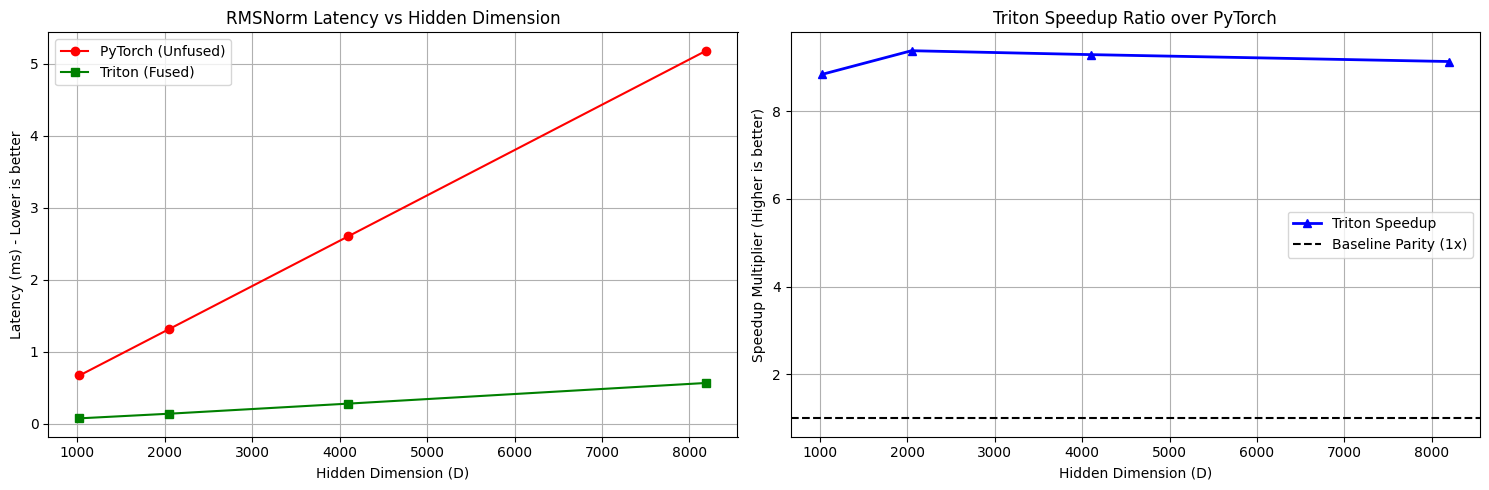

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

@triton.autotune(
    configs=[
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
        triton.Config({}, num_warps=16),
    ],
    key=['N_COLS']
)
@triton.jit
def rmsnorm_forward_kernel(
    X_ptr, Y_ptr, W_ptr, 
    stride_x_row, stride_y_row, 
    N_COLS, eps,
    BLOCK_SIZE: tl.constexpr
):
    row_idx = tl.program_id(0)
    
    X_row_ptr = X_ptr + row_idx * stride_x_row
    Y_row_ptr = Y_ptr + row_idx * stride_y_row
    
    cols = tl.arange(0, BLOCK_SIZE)
    mask = cols < N_COLS
    
    x = tl.load(X_row_ptr + cols, mask=mask, other=0.0).to(tl.float32)
    w = tl.load(W_ptr + cols, mask=mask, other=0.0).to(tl.float32)
    
    # Compute Variance in FP32
    x_squared = x * x
    variance = tl.sum(x_squared, axis=0) / N_COLS
    
    # Normalize
    rsqrt = tl.math.rsqrt(variance + eps)
    y = x * rsqrt * w
    
    # Store back as FP16
    tl.store(Y_row_ptr + cols, y.to(tl.float16), mask=mask)

def triton_rmsnorm(x, weight, eps=1e-6):
    M_ROWS, N_COLS = x.shape
    y = torch.empty_like(x)
    
    BLOCK_SIZE = triton.next_power_of_2(N_COLS)
    
    grid = lambda META: (M_ROWS,)
    
    rmsnorm_forward_kernel[grid](
        x, y, weight,
        x.stride(0), y.stride(0),
        N_COLS, eps,
        BLOCK_SIZE=BLOCK_SIZE # Pass it explicitly
    )
    return y

def pytorch_rmsnorm(x, weight, eps=1e-6):
    x_fp32 = x.to(torch.float32)
    variance = x_fp32.pow(2).mean(-1, keepdim=True)
    x_norm = x_fp32 * torch.rsqrt(variance + eps)
    
    # Cast back to fp16 and multiply by weights
    return weight * x_norm.to(x.dtype)

def evaluate_rmsnorm():
    print("Evaluating Fused RMSNorm...")
    hidden_dims = [1024, 2048, 4096, 8192]
    batch_seq = 4096
    results = []

    for D in hidden_dims:
        print(f"Testing Hidden Dim: {D}...")
        x = torch.randn((batch_seq, D), device='cuda', dtype=torch.float16)
        weight = torch.ones(D, device='cuda', dtype=torch.float16)
        
        out_pt = pytorch_rmsnorm(x, weight)
        out_tr = triton_rmsnorm(x, weight)
        
        try:
            torch.testing.assert_close(out_tr, out_pt, atol=1e-3, rtol=1e-3)
        except AssertionError as e:
            print(f"  [!] Correctness Failed at D={D}")
            print(e)
            break
        
        # 2. Latency Benchmarking
        ms_pt = triton.testing.do_bench(lambda: pytorch_rmsnorm(x, weight))
        ms_tr = triton.testing.do_bench(lambda: triton_rmsnorm(x, weight))
        
        results.append({
            'Hidden_Dim': D,
            'PyTorch_ms': ms_pt,
            'Triton_ms': ms_tr,
            'Speedup': ms_pt / ms_tr
        })

    df = pd.DataFrame(results)
    print("\n=== RMSNORM METRICS ===")
    print(df.to_string(index=False))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Latency Comparison
    ax1.plot(df['Hidden_Dim'], df['PyTorch_ms'], label='PyTorch (Unfused)', marker='o', color='red')
    ax1.plot(df['Hidden_Dim'], df['Triton_ms'], label='Triton (Fused)', marker='s', color='green')
    ax1.set_title('RMSNorm Latency vs Hidden Dimension')
    ax1.set_xlabel('Hidden Dimension (D)')
    ax1.set_ylabel('Latency (ms) - Lower is better')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Speedup Multiplier
    ax2.plot(df['Hidden_Dim'], df['Speedup'], label='Triton Speedup', marker='^', color='blue', linewidth=2)
    ax2.axhline(1.0, color='black', linestyle='--', label='Baseline Parity (1x)')
    ax2.set_title('Triton Speedup Ratio over PyTorch')
    ax2.set_xlabel('Hidden Dimension (D)')
    ax2.set_ylabel('Speedup Multiplier (Higher is better)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

evaluate_rmsnorm()

## --------- Fused Rotary Positional Embeddings (RoPE) ------------

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


@triton.autotune(
    configs=[
        triton.Config({'BLOCK_S': 64}, num_warps=4),
        triton.Config({'BLOCK_S': 128}, num_warps=4),
        triton.Config({'BLOCK_S': 128}, num_warps=8),
    ],
    key=['seq_len']
)
@triton.jit
def fused_rope_kernel_2d(
    Q_ptr, Out_ptr, Cos_ptr, Sin_ptr,
    stride_qb, stride_qh, stride_qs, stride_qd,
    stride_ob, stride_oh, stride_os, stride_od,
    stride_cs, stride_cd,
    seq_len,
    BLOCK_S: tl.constexpr,
    HALF_D: tl.constexpr
):
    batch_idx = tl.program_id(0)
    head_idx = tl.program_id(1)
    seq_block_idx = tl.program_id(2)

    # 2D Offsets
    offs_s = seq_block_idx * BLOCK_S + tl.arange(0, BLOCK_S)
    offs_d1 = tl.arange(0, HALF_D)
    offs_d2 = HALF_D + tl.arange(0, HALF_D)

    # Mask for sequence bounds
    mask_s = offs_s < seq_len

    # Base Pointers for Batch and Head
    q_base = Q_ptr + batch_idx * stride_qb + head_idx * stride_qh
    out_base = Out_ptr + batch_idx * stride_ob + head_idx * stride_oh

    # 2D Pointer Grids
    q1_ptrs = q_base + offs_s[:, None] * stride_qs + offs_d1[None, :] * stride_qd
    q2_ptrs = q_base + offs_s[:, None] * stride_qs + offs_d2[None, :] * stride_qd
    
    cos_ptrs = Cos_ptr + offs_s[:, None] * stride_cs + offs_d1[None, :] * stride_cd
    sin_ptrs = Sin_ptr + offs_s[:, None] * stride_cs + offs_d1[None, :] * stride_cd

    # Load into SRAM and cast to FP32 for math stability
    q1 = tl.load(q1_ptrs, mask=mask_s[:, None], other=0.0).to(tl.float32)
    q2 = tl.load(q2_ptrs, mask=mask_s[:, None], other=0.0).to(tl.float32)
    cos = tl.load(cos_ptrs, mask=mask_s[:, None], other=0.0).to(tl.float32)
    sin = tl.load(sin_ptrs, mask=mask_s[:, None], other=0.0).to(tl.float32)

    # RoPE Math
    out1 = q1 * cos - q2 * sin
    out2 = q2 * cos + q1 * sin

    # Output Pointers
    out1_ptrs = out_base + offs_s[:, None] * stride_os + offs_d1[None, :] * stride_od
    out2_ptrs = out_base + offs_s[:, None] * stride_os + offs_d2[None, :] * stride_od

    # Store directly back to HBM
    tl.store(out1_ptrs, out1.to(tl.float16), mask=mask_s[:, None])
    tl.store(out2_ptrs, out2.to(tl.float16), mask=mask_s[:, None])


def triton_apply_rope(q, cos, sin):
    out = torch.empty_like(q)
    B, H, S, D = out.shape
    
    # 3D Grid: (Batch, Head, Number of Sequence Blocks)
    # BLOCK_S is dynamically injected by the autotuner
    grid = lambda META: (B, H, triton.cdiv(S, META['BLOCK_S']))
    
    fused_rope_kernel_2d[grid](
        q, out, cos, sin,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        out.stride(0), out.stride(1), out.stride(2), out.stride(3),
        cos.stride(0), cos.stride(1),
        seq_len=S,
        HALF_D=D // 2
    )
    return out

# def rotate_half(x):
#     x1, x2 = x[..., :x.shape[-1] // 2], x[..., x.shape[-1] // 2:]
#     return torch.cat((-x2, x1), dim=-1)

def pytorch_apply_rope(q, cos, sin):
    q_fp32 = q.to(torch.float32)
    cos_fp32 = cos.unsqueeze(0).unsqueeze(0).to(torch.float32)
    sin_fp32 = sin.unsqueeze(0).unsqueeze(0).to(torch.float32)
    
    cos_fp32 = torch.cat([cos_fp32, cos_fp32], dim=-1)
    sin_fp32 = torch.cat([sin_fp32, sin_fp32], dim=-1)
    
    def rotate_half_fp32(x):
        x1, x2 = x[..., :x.shape[-1] // 2], x[..., x.shape[-1] // 2:]
        return torch.cat((-x2, x1), dim=-1)
    
    out = (q_fp32 * cos_fp32) + (rotate_half_fp32(q_fp32) * sin_fp32)
    return out.to(q.dtype) # Cast back to fp16


def evaluate_rope():
    print("Starting Fused RoPE Evaluation (2D Tiled)...\n")
    B, H, D = 4, 32, 64 
    seq_lengths = [1024, 2048, 4096, 8192]
    
    results = []

    for S in seq_lengths:
        print(f"Testing Sequence Length: {S}...")
        q = torch.randn((B, H, S, D), device='cuda', dtype=torch.float16)
        cos = torch.randn((S, D // 2), device='cuda', dtype=torch.float16)
        sin = torch.randn((S, D // 2), device='cuda', dtype=torch.float16)

        out_pt = pytorch_apply_rope(q, cos, sin)
        out_tr = triton_apply_rope(q, cos, sin)
        
        try:
            torch.testing.assert_close(out_tr, out_pt, atol=5e-3, rtol=1e-3)
        except AssertionError as e:
            print(f"  [!] Correctness Failed at S={S}")
            print(e)
            break

        ms_pt = triton.testing.do_bench(lambda: pytorch_apply_rope(q, cos, sin))
        ms_tr = triton.testing.do_bench(lambda: triton_apply_rope(q, cos, sin))
        
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = pytorch_apply_rope(q, cos, sin)
        vram_pt = torch.cuda.max_memory_allocated() / (1024**2)

        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        _ = triton_apply_rope(q, cos, sin)
        vram_tr = torch.cuda.max_memory_allocated() / (1024**2)

        results.append({
            'Seq_Len': S,
            'PyTorch_ms': ms_pt,
            'Triton_ms': ms_tr,
            'PyTorch_VRAM_MB': vram_pt,
            'Triton_VRAM_MB': vram_tr,
            'Speedup': ms_pt / ms_tr
        })

    df = pd.DataFrame(results)
    print("\n=== ROPE METRICS ===")
    print(df.to_string(index=False))

evaluate_rope()

Starting Fused RoPE Evaluation (2D Tiled)...

Testing Sequence Length: 1024...
Testing Sequence Length: 2048...
Testing Sequence Length: 4096...
Testing Sequence Length: 8192...

=== ROPE METRICS ===
 Seq_Len  PyTorch_ms  Triton_ms  PyTorch_VRAM_MB  Triton_VRAM_MB   Speedup
    1024    1.921835   0.151917          224.750         128.250 12.650590
    2048    3.818247   0.298657          417.375         208.375 12.784704
    4096    8.094157   0.588259          786.625         368.625 13.759517
    8192   17.270003   1.165764         1525.125         689.125 14.814316


In [5]:
%ls

sample_data/


In [1]:
!git clone https://github.com/darshanlahamage/Trition-kernel-fusion-inference-profiler.git

Cloning into 'Trition-kernel-fusion-inference-profiler'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 47 (delta 16), reused 41 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 309.93 KiB | 2.54 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [3]:
%cd /content/Trition-kernel-fusion-inference-profiler/src

/content/Trition-kernel-fusion-inference-profiler/src


In [4]:
!pip install -e .

Obtaining file:///content/Trition-kernel-fusion-inference-profiler/src
  Preparing metadata (setup.py) ... done
  Running setup.py develop for triton_llm_engine


In [10]:
!git pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 2.30 KiB | 106.00 KiB/s, done.
From https://github.com/darshanlahamage/Trition-kernel-fusion-inference-profiler
   5f6419e..9fe062f  main       -> origin/main
Updating 5f6419e..9fe062f
Fast-forward
 notebooks/fused-kernel.ipynb |  32 ++++++-------
 src/benchmark.py             | 105 ++++++++++++++++++++++++++-----------------
 2 files changed, 80 insertions(+), 57 deletions(-)


In [11]:
!python benchmark.py


Triton Kernel Fusion Profiler
Architecture: 8 Layers | 512 Dim | 16 Heads
Workload: Batch 4 | Prompt 2048 tokens | Gen 20 tokens
Model Params: 35.41 M (FP16)
------------------------------------------------------------
[1/3] Running Triton JIT Warmup...
[2/3] Profiling Optimized Triton Engine (KV-Cache Enabled)...
[3/3] Profiling Naive PyTorch Baseline (No KV-Cache)...

Performance Report
Metric                    | PyTorch Eager   | Triton Optimized | Delta / Improvement
-------------------------------------------------------------------------------------
Prefill TTFT              | -               | 1294.62 ms      | -
Decode Throughput         |    1.5 tok/s    |   14.4 tok/s    | 9.7x Speedup
Peak VRAM                 |   668.3 MB     |   633.2 MB     | 35.1 MB Saved
-------------------------------------------------------------------------------------

[Analysis]
By fusing kernels and utilizing a stateful KV-Cache, the Triton Engine reduces computational complexity from O(N^2) to 